<a href="https://colab.research.google.com/github/aditya-srivastava010/KAMADO-999-AI-ML-TRAINNING/blob/main/Car_Price_Prediction_LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚗 Car Price Prediction — Linear Regression
**Dataset:** car_prediction_data.csv (301 rows, 9 columns)

**Target Variable:** `Selling_Price`

---

## Step 1 — Libraries Import

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2 — Dataset Load karo
Yeh dataset **301 rows** aur **9 columns** ka hai.

**Columns:**
- `Car_Name` — Car ka naam
- `Year` — Manufacturing year
- `Selling_Price` — 🎯 **TARGET** (yahi predict karna hai)
- `Present_Price` — Showroom price
- `Kms_Driven` — Kitne km chali
- `Fuel_Type` — Petrol / Diesel / CNG
- `Seller_Type` — Dealer / Individual
- `Transmission` — Manual / Automatic
- `Owner` — Kitne logon ne use ki

In [7]:
df = pd.read_csv('car_prediction_data.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (301, 9)

First 5 rows:


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 3 — EDA Part 1: Basic Info

In [8]:
print('=== DATA TYPES ===')
print(df.dtypes)

print('\n=== NULL VALUES ===')
print(df.isnull().sum())

print('\n=== STATISTICAL SUMMARY ===')
df.describe()

=== DATA TYPES ===
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object

=== NULL VALUES ===
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

=== STATISTICAL SUMMARY ===


,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## Step 4 — EDA Part 2: Car Age Feature Banana
`Year` column directly useful nahi hai. Isliye `Car_Age` banate hain:

`Car_Age = 2024 - Year`

Purani car hogi → zyada driven → kam price. Yeh zyada logical feature hai.

In [9]:
df['Car_Age'] = 2024 - df['Year']

print('Car_Age column add ho gayi!')
print(df[['Car_Name', 'Year', 'Car_Age', 'Selling_Price']].head(10))

Car_Age column add ho gayi!
        Car_Name  Year  Car_Age  Selling_Price
0           ritz  2014       10           3.35
1            sx4  2013       11           4.75
2           ciaz  2017        7           7.25
3        wagon r  2011       13           2.85
4          swift  2014       10           4.60
5  vitara brezza  2018        6           9.25
6           ciaz  2015        9           6.75
7        s cross  2015        9           6.50
8           ciaz  2016        8           8.75
9           ciaz  2015        9           7.45


## Step 5 — EDA Part 3: Visualizations
### 5a. Selling Price Distribution

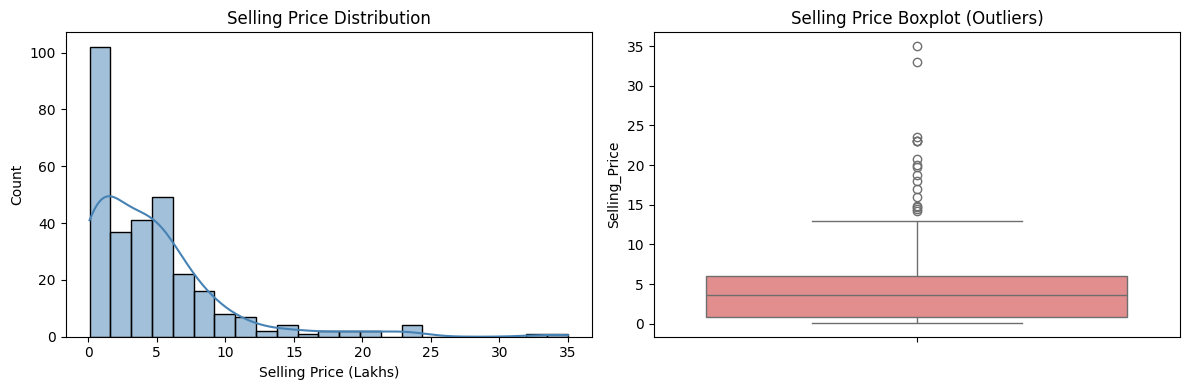

In [10]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['Selling_Price'], kde=True, color='steelblue')
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price (Lakhs)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Selling_Price'], color='lightcoral')
plt.title('Selling Price Boxplot (Outliers)')

plt.tight_layout()
plt.show()

### 5b. Present Price vs Selling Price

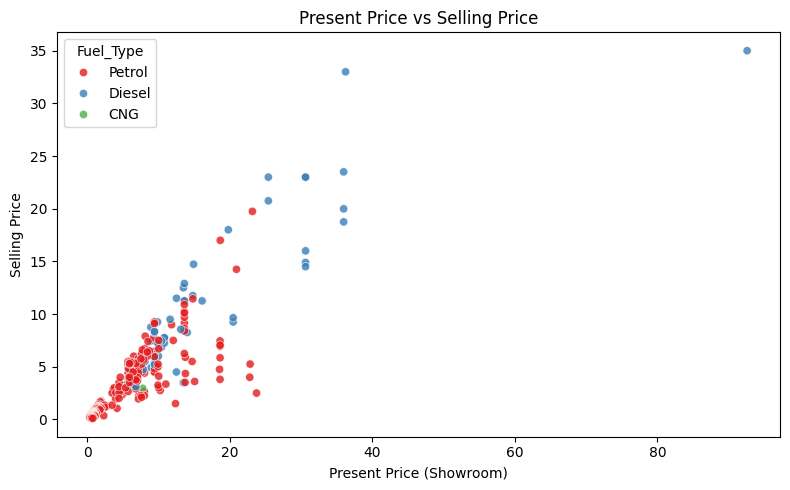

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Present_Price', y='Selling_Price', data=df,
                hue='Fuel_Type', palette='Set1', alpha=0.8)
plt.title('Present Price vs Selling Price')
plt.xlabel('Present Price (Showroom)')
plt.ylabel('Selling Price')
plt.tight_layout()
plt.show()

### 5c. Car Age vs Selling Price

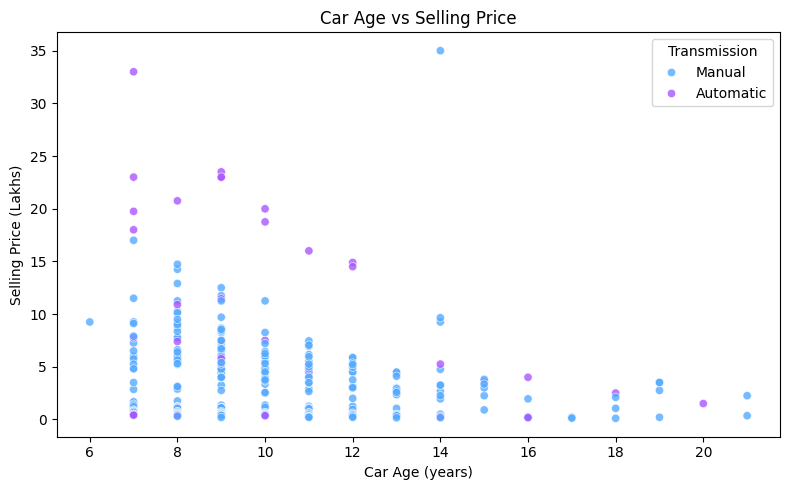

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Car_Age', y='Selling_Price', data=df,
                hue='Transmission', palette='cool', alpha=0.8)
plt.title('Car Age vs Selling Price')
plt.xlabel('Car Age (years)')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

### 5d. Fuel Type vs Selling Price

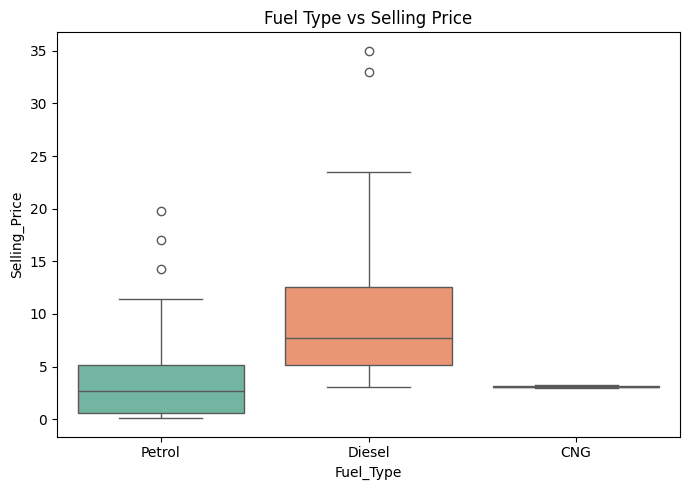

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=df, palette='Set2')
plt.title('Fuel Type vs Selling Price')
plt.tight_layout()
plt.show()

### 5e. Seller Type vs Selling Price

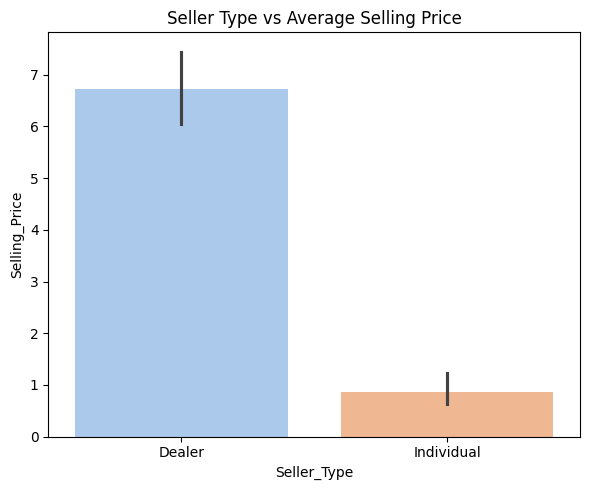

In [14]:
plt.figure(figsize=(6, 5))
sns.barplot(x='Seller_Type', y='Selling_Price', data=df, palette='pastel')
plt.title('Seller Type vs Average Selling Price')
plt.tight_layout()
plt.show()

### 5f. Correlation Heatmap

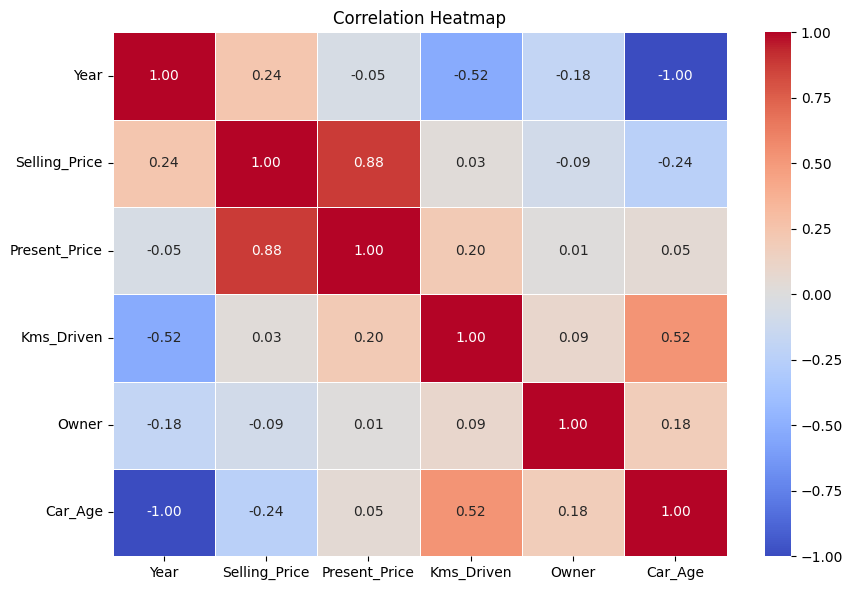

In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 5g. Kms Driven vs Selling Price

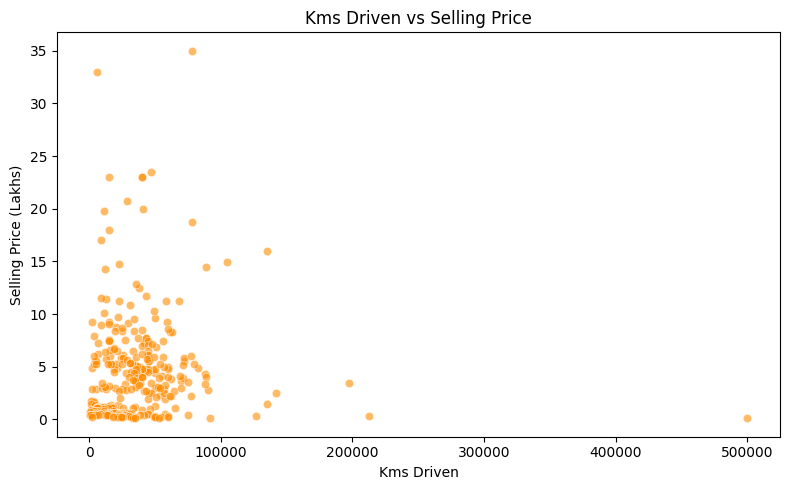

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Kms_Driven', y='Selling_Price', data=df, color='darkorange', alpha=0.6)
plt.title('Kms Driven vs Selling Price')
plt.xlabel('Kms Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

## Step 6 — Outlier Removal (IQR Method)
Selling_Price aur Kms_Driven mein outliers hain.

In [17]:
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return dataframe[(dataframe[column] >= lower) & (dataframe[column] <= upper)]

print(f'Before: {df.shape[0]} rows')
df = remove_outliers_iqr(df, 'Selling_Price')
df = remove_outliers_iqr(df, 'Kms_Driven')
print(f'After:  {df.shape[0]} rows')

Before: 301 rows
After:  278 rows


## Step 7 — Feature Engineering
### 7a. Categorical Encoding (Label Encoding)

In [18]:
le = LabelEncoder()

cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('Label Encoding done!')
print('\nEncoded values:')
df[cat_cols].head()

Label Encoding done!

Encoded values:


,Fuel_Type,Seller_Type,Transmission
0,2,0,1
1,1,0,1
2,2,0,1
3,2,0,1
4,1,0,1


### 7b. Features aur Target Select karo

In [19]:
# Car_Name aur Year drop karo (Car_Age already hai)
features = ['Present_Price', 'Kms_Driven', 'Fuel_Type',
            'Seller_Type', 'Transmission', 'Owner', 'Car_Age']

X = df[features]
y = df['Selling_Price']

print('Features (X):', list(X.columns))
print('Target  (y): Selling_Price')
print('X shape:', X.shape)

Features (X): ['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'Car_Age']
Target  (y): Selling_Price
X shape: (278, 7)


### 7c. Train/Test Split + StandardScaler

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train size: {X_train.shape[0]} rows')
print(f'Test size:  {X_test.shape[0]} rows')

Train size: 222 rows
Test size:  56 rows


## Step 8 — Model Training

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')
print('\nCoefficients (har feature ka weight):')
for feat, coef in zip(features, model.coef_):
    print(f'  {feat:20s}: {coef:.4f}')
print(f'\nIntercept: {model.intercept_:.4f}')

Model trained successfully!

Coefficients (har feature ka weight):
  Present_Price       : 2.1356
  Kms_Driven          : -0.4046
  Fuel_Type           : -0.3799
  Seller_Type         : -0.7010
  Transmission        : -0.0903
  Owner               : 0.0747
  Car_Age             : -0.7062

Intercept: 3.7302


## Step 9 — Model Evaluation

In [22]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('===============================')
print('     MODEL EVALUATION')
print('===============================')
print(f'MAE  : {mae:.4f}  (avg error in lakhs)')
print(f'MSE  : {mse:.4f}')
print(f'RMSE : {rmse:.4f}')
print(f'R²   : {r2:.4f}  ({r2*100:.2f}% accuracy)')
print('===============================')

     MODEL EVALUATION
MAE  : 1.0593  (avg error in lakhs)
MSE  : 2.3178
RMSE : 1.5224
R²   : 0.7852  (78.52% accuracy)


## Step 10 — Predicted vs Actual Plot

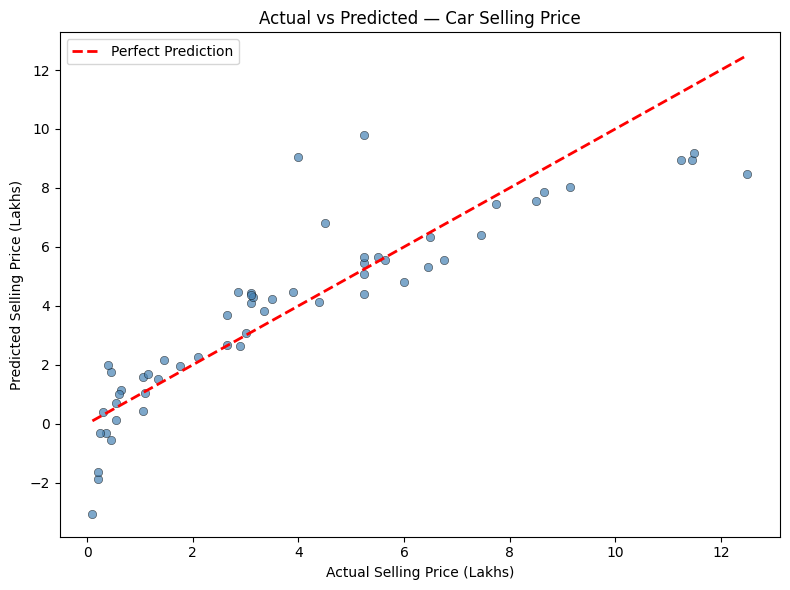

In [23]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7, edgecolors='k', linewidths=0.4)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Selling Price (Lakhs)')
plt.ylabel('Predicted Selling Price (Lakhs)')
plt.title('Actual vs Predicted — Car Selling Price')
plt.legend()
plt.tight_layout()
plt.show()

## Step 11 — Residual Plot

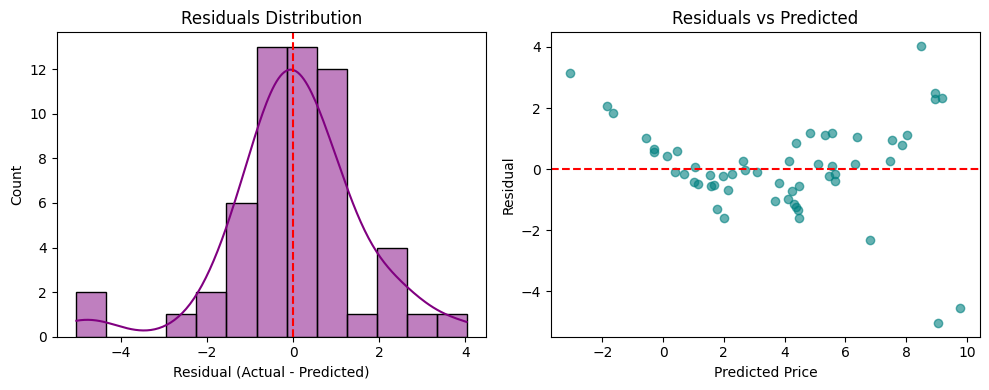

In [24]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution')
plt.xlabel('Residual (Actual - Predicted)')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, color='teal', alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals vs Predicted')
plt.xlabel('Predicted Price')
plt.ylabel('Residual')

plt.tight_layout()
plt.show()

## Step 12 — Feature Importance (Coefficients)

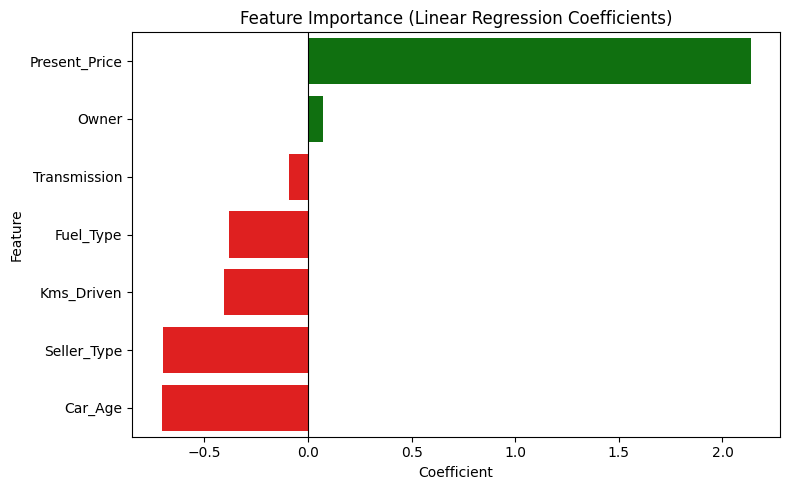

         Feature  Coefficient
0  Present_Price     2.135612
5          Owner     0.074664
4   Transmission    -0.090328
2      Fuel_Type    -0.379893
1     Kms_Driven    -0.404585
3    Seller_Type    -0.700995
6        Car_Age    -0.706222


In [25]:
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df,
            palette=['green' if c > 0 else 'red' for c in coef_df['Coefficient']])
plt.title('Feature Importance (Linear Regression Coefficients)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print(coef_df)

## Step 13 — Conclusion

### 📝 Summary

| Metric | Value |
|--------|-------|
| Dataset | 301 rows, 9 columns |
| Target | Selling_Price |
| Algorithm | Linear Regression |
| Train/Test Split | 80% / 20% |

### 🔍 Key Findings
1. **Present_Price** sabse important feature hai — showroom price zyada → selling price bhi zyada
2. **Car_Age** negative impact karta hai — purani car → kam price
3. **Diesel cars** petrol se thodi zyada price pe bik ti hain
4. **Dealer** se bachi cars individual seller se zyada price pe bik ti hain
5. Residuals roughly normally distributed hain — model theek hai

### ✅ Model Performance
- R² score batata hai model kitni variation explain kar sakta hai
- MAE batata hai average mein kitne lakhs ka error hai
